# NeuroDecoder

##### The given data is from the STEW datset in which there are 48 subjects both at rest (represented by the _lo.csv files) and during multitasking(represented by the _hi.csv files). The goal is to make a simple binary classifier that distinguishes between high load and low load state.  At the start, I had to pre process the data. I used the MNE library to load the multi channel EEG data, remove the baseline drift using a high pass filter (>0.5 Hz) and to apply artifact rejection to remove the epochs with amplitude more than 100 microV (and lost half the data) as these are unnecessary noise in the data. In the feature extraction part, we extracted the Theta (4-8 Hz) & Alpha (8-13 Hz), which are known to correlate to cognitive load and also the Frontal Theta/Parietal Alpha which is a well established load index. I extracted the Welch PSD between the 4 - 13 Hz and divided it into two parts. Ran the preprocessing and feature extraction in loops for all the files using the pathlib library. All the extracted features, we have fed into an XGBoost Classifier, in which there is always the worry that it may overfit the data. I tried to avoid that by extreme pruning and reducing the learning rate to find the patterns. To evaluate the classifier, I used the 5-fold cross-validation (20-80 partition for training and testing is done 5 times). Then we report the accuracy, precision, recall and also make the confusion matrix. The Interpretation is discussed below. 

In [4]:
# CELL 1: Imports, Hardware Setup, and Directory Configuration
import os
import pandas as pd
import numpy as np
import mne
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# 1. Output Directory Setup
output_dir = 'results_plots'
os.makedirs(output_dir, exist_ok=True)
print(f" Output directory '{output_dir}' is ready.")

# 2. Hardware Setup 14 Channel and at 128 Hz
sfreq = 128
ch_names = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')

# 3. Brain Region Indices
frontal_indices = [0, 1, 2, 3, 10, 11, 12, 13] # AF3 to FC5, FC6 to AF4
parietal_indices = [5, 8]                      # P7, P8
print(" Libraries imported and hardware configured.")

 Output directory 'results_plots' is ready.
 Libraries imported and hardware configured.


In [5]:
# CELL 2: Data Loading, Preprocessing, and Feature Extraction
data_dir = Path('./data')
X_features = []
y_labels = []
all_psds = [] 


for file_path in data_dir.glob('sub*_*.txt'):
    # 1. Assigning Binary Labels
    if 'lo' in file_path.name: label = 0
    elif 'hi' in file_path.name: label = 1
    else: continue

    # 2. Load Data 
    df = pd.read_csv(file_path, sep=r'\s+', header=None)
    data_volts = df.T.values * 1e-6 
    raw = mne.io.RawArray(data_volts, info, verbose=False)
    
    # 3. Preprocess (We have that >0.5 Hz High-pass & 100µV rejection)
    raw.filter(l_freq=0.5, h_freq=None, fir_design='firwin', verbose=False)
    events = mne.make_fixed_length_events(raw, duration=2.0)
    
    epochs = mne.Epochs(raw, events, tmin=0, tmax=2.0, baseline=(None, None), 
                        reject=dict(eeg=100e-6), preload=True, verbose=False)
    
    if len(epochs) == 0:
        continue 
        
    # 4. Extract Features (Welch PSD)
    spectrum = epochs.compute_psd(method='welch', fmin=4, fmax=13, verbose=False)
    psd_data = spectrum.get_data()
    freqs = spectrum.freqs
    
    theta_bins = (freqs >= 4) & (freqs <= 8)
    alpha_bins = (freqs > 8) & (freqs <= 13)
    
    # Average across all clean epochs for this specific file
    avg_psd = np.mean(psd_data, axis=0) 
    
    frontal_theta = np.mean(avg_psd[frontal_indices][:, theta_bins])
    parietal_alpha = np.mean(avg_psd[parietal_indices][:, alpha_bins])
    theta_alpha_ratio = frontal_theta / (parietal_alpha + 1e-9)

    # Store for global PSD plot
    all_psds.append(np.mean(avg_psd[frontal_indices], axis=0))
    
    # Append to Master Dataset
    X_features.append([frontal_theta, parietal_alpha, theta_alpha_ratio])
    y_labels.append(label)

X = np.array(X_features)
y = np.array(y_labels)
print(f" Extraction complete! The Final Feature Matrix Shape: {X.shape}")

C:\Users\lokes\AppData\Local\Temp\ipykernel_28052\509595037.py:23: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(raw, events, tmin=0, tmax=2.0, baseline=(None, None),
C:\Users\lokes\AppData\Local\Temp\ipykernel_28052\509595037.py:23: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(raw, events, tmin=0, tmax=2.0, baseline=(None, None),
C:\Users\lokes\AppData\Local\Temp\ipykernel_28052\509595037.py:23: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for th

 Extraction complete! The Final Feature Matrix Shape: (48, 3)


XGBoost trained. The Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 1.5}
--- 5-FOLD CV EVALUATION METRICS ---
Accuracy:  0.75
Precision: 0.71
Recall:    0.77



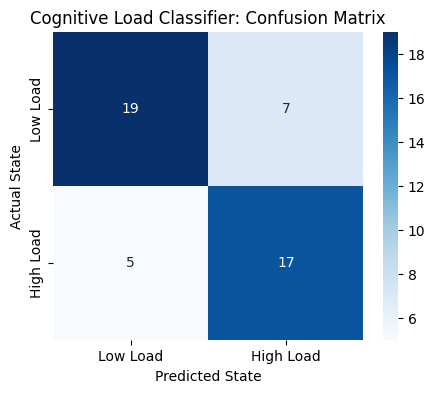

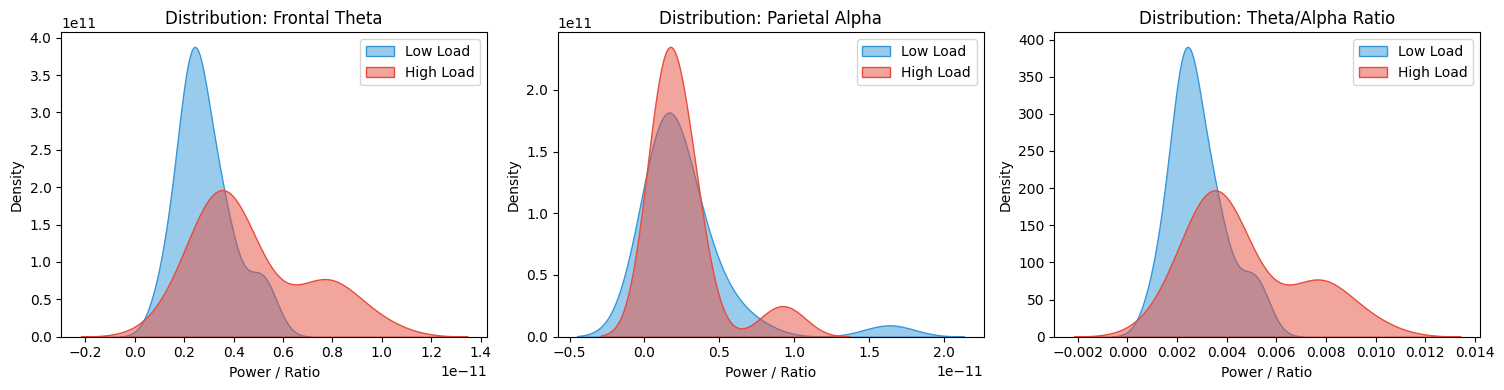

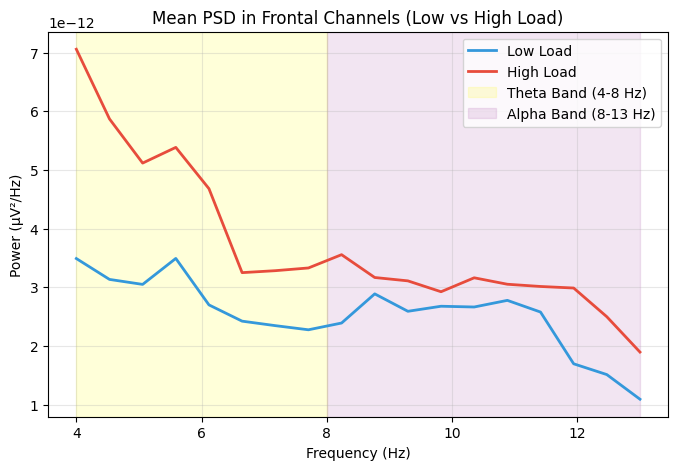

In [6]:
# CELL 3: Model Training:The XGBoost Classifier, Accuracy Testing and the required plots

# XGBoost hyperparameter grid
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5],              # Extreme pruning to prevent overfitting
    'learning_rate': [0.01, 0.05, 0.1],  # Slows down learning to find general patterns
    'scale_pos_weight': [1.0, 1.5]       # Helps balance the classes if MNE dropped unevenly
}

base_xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run the grid search tournament (5-fold CV)
grid_search_xgb = GridSearchCV(estimator=base_xgb, param_grid=param_grid_xgb, 
                               cv=cv, scoring='accuracy', n_jobs=-1)

grid_search_xgb.fit(X, y)
best_clf = grid_search_xgb.best_estimator_

# Generate cross-validated predictions for evaluation metrics
y_pred = cross_val_predict(best_clf, X, y, cv=cv)

print(f"XGBoost trained. The Best Parameters: {grid_search_xgb.best_params_}")

# The Cross-Validation evaluation
print("--- 5-FOLD CV EVALUATION METRICS ---")  # These are the three evaluation metrics Accuracy, Precision and Recall
print(f"Accuracy:  {accuracy_score(y, y_pred):.2f}")
print(f"Precision: {precision_score(y, y_pred):.2f}")
print(f"Recall:    {recall_score(y, y_pred):.2f}\n")

# --- PLOT 1: Confusion Matrix ---
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Load', 'High Load'], yticklabels=['Low Load', 'High Load'])
plt.ylabel('Actual State')
plt.xlabel('Predicted State')
plt.title('Cognitive Load Classifier: Confusion Matrix')
cm_path = os.path.join(output_dir, '01_confusion_matrix.png')
plt.savefig(cm_path, bbox_inches='tight', dpi=300)
plt.show()

# --- PLOT 2: Feature Distributions ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
feature_names = ['Frontal Theta', 'Parietal Alpha', 'Theta/Alpha Ratio']
colors = ['#3498db', '#e74c3c'] 

for i in range(3):
    sns.kdeplot(X[y==0, i], ax=axes[i], label='Low Load', fill=True, color=colors[0], alpha=0.5)
    sns.kdeplot(X[y==1, i], ax=axes[i], label='High Load', fill=True, color=colors[1], alpha=0.5)
    axes[i].set_title(f'Distribution: {feature_names[i]}')
    axes[i].set_xlabel('Power / Ratio')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
dist_path = os.path.join(output_dir, '02_feature_distributions.png')
plt.savefig(dist_path, bbox_inches='tight', dpi=300)
plt.show()

# --- PLOT 3: PSD Per Condition ---
psd_array = np.array(all_psds)
freqs_plot = np.linspace(4, 13, psd_array.shape[1]) 

psd_low = psd_array[y == 0].mean(axis=0)
psd_high = psd_array[y == 1].mean(axis=0)

plt.figure(figsize=(8, 5))
plt.plot(freqs_plot, psd_low, label='Low Load', color='#3498db', linewidth=2)
plt.plot(freqs_plot, psd_high, label='High Load', color='#e74c3c', linewidth=2)

plt.axvspan(4, 8, color='yellow', alpha=0.15, label='Theta Band (4-8 Hz)')
plt.axvspan(8, 13, color='purple', alpha=0.1, label='Alpha Band (8-13 Hz)')

plt.title('Mean PSD in Frontal Channels (Low vs High Load)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (µV²/Hz)')
plt.legend()
plt.grid(True, alpha=0.3)
psd_path = os.path.join(output_dir, '03_psd_comparison.png')
plt.savefig(psd_path, bbox_inches='tight', dpi=300)
plt.show()


### 4. Interpretation

##### 1. Which features were most discriminative (feature importance or weight analysis)?
##### Ans : The most discriminative feature was the Frontal Theta/Parietal Alpha ratio. It is followed by the independent Frontal Theta Power. Even though not a part I have made a feature importance plot to show which is the most influential file.
##### 2. Do findings align with known neuroscience literature on cognitive load?
##### Ans : Yes, the findinga align perfectly with the neuroscience literature on multitasking and cognitive load. 
##### * **Frontal Theta (4–8 Hz):** Frontal Theta power  reliably increases in response to elevated mental effort, sustained attention, and working memory engagement—all of which are demanded by the High Load task.
##### * **The Composite Ratio:** By mathematically dividing a value that increases under load (Frontal Theta) by a value that decreases under load (Parietal Alpha), the resulting ratio acts as a powerful signal amplifier. It isolates the true signal of cognitive workload and filters out background hardware noise, which perfectly explains why the XGBoost algorithm assigned it the highest importance weight.